In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
import numpy as np

import re
import string
import emoji
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import sklearn
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score, roc_curve, auc, confusion_matrix

In [ ]:
print("Pandas :", pd.__version__)
print("Numpy :", np.__version__)
print("NLTK :", nltk.__version__)
print("Matplotlib :", matplotlib.__version__)
print("RE :", re.__version__)
print("Seaborn :", sns.__version__)
print("Emoji :", emoji.__version__)
print("SK :", sklearn.__version__)

Pandas : 2.2.2
Numpy : 2.0.2
NLTK : 3.9.1
Matplotlib : 3.10.0
RE : 2.2.1
Seaborn : 0.13.2
Emoji : 2.15.0
SK : 1.6.1


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
val = pd.read_csv("dev.csv")

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
train = pd.concat([train, val], axis=0, ignore_index=True)

In [ ]:
train.shape[0]

16000

In [ ]:
train.duplicated().any()

np.False_

In [ ]:
train.head()

,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-16993,"Then, she's a keeper. 😉",not sexist,none,none,train
1,sexism2022_english-13149,This is like the Metallica video where the poo...,not sexist,none,none,train
2,sexism2022_english-13021,woman?,not sexist,none,none,train
3,sexism2022_english-14998,Unlicensed day care worker reportedly tells co...,not sexist,none,none,train
4,sexism2022_english-7228,[USER] Leg day is easy. Hot girls who wear min...,sexist,3. animosity,3.3 backhanded gendered compliments,train


In [ ]:
train.drop(columns=['rewire_id', 'label_category', 'label_vector', 'split'], inplace=True)
test.drop(columns=['rewire_id', 'label_category', 'label_vector', 'split'], inplace=True)

In [ ]:
def change_column_names(df, text_col, label_col):
    return df.rename(columns={ text_col: "text", label_col: "target"})

In [ ]:
train = change_column_names(train, "text", "label_sexist")
test = change_column_names(test, "text", "label_sexist")

In [ ]:
train.head()

,text,target
0,"Then, she's a keeper. 😉",not sexist
1,This is like the Metallica video where the poo...,not sexist
2,woman?,not sexist
3,Unlicensed day care worker reportedly tells co...,not sexist
4,[USER] Leg day is easy. Hot girls who wear min...,sexist


In [ ]:
stop_words = set(stopwords.words("english"))
negations = {"no", "not", "nor", "never"}
stop_words = stop_words - negations

In [ ]:
stemmer = PorterStemmer()

In [ ]:
def clean_text(text: str) -> str:
    text = text.lower()

    text = emoji.demojize(text, delimiters=(" ", " "))

    text = re.sub(r"http\S+|www\S+", " URL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"\d+", " NUM ", text)

    text = re.sub(r"!{2,}", " EXCLAMATION ", text)
    text = re.sub(r"\?{2,}", " QUESTION ", text)

    punctuation = string.punctuation.replace("_", "")
    text = text.translate(str.maketrans("", "", punctuation))

    tokens = text.split()

    tokens = [
        stemmer.stem(token)
        for token in tokens
        if token not in stop_words
    ]

    return " ".join(tokens)


In [ ]:
print(train['target'].value_counts())
print(test['target'].value_counts())

target
not sexist    12116
sexist         3884
Name: count, dtype: int64
target
not sexist    3030
sexist         970
Name: count, dtype: int64


In [ ]:
train["clean_text"] = train["text"].apply(clean_text)
test["clean_text"] = test["text"].apply(clean_text)

In [ ]:
train.columns

Index(['text', 'target', 'clean_text'], dtype='object')

In [ ]:
label_map = {
    "not sexist": 0,
    "sexist": 1
}

In [ ]:
train["target"] = train["target"].str.strip().str.lower().map(label_map)
test["target"] = test["target"].str.strip().str.lower().map(label_map)

In [ ]:
x_train = train['clean_text'].values
x_test = test['clean_text'].values

y_train = train['target'].values
y_test = test['target'].values

In [ ]:
log_reg_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        solver='saga',
        max_iter=3000,
        class_weight='balanced'
    ))
])

In [ ]:
svc_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9
    )),
    ('svc', LinearSVC(max_iter=3000))
])

In [ ]:
rfc_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9, sublinear_tf=True)),
    ('rfc', RandomForestClassifier())
])

In [ ]:
log_reg_param_grid = {
    'clf__C': np.logspace(-3, 2, 20),
    'clf__penalty': ['l1', 'l2']
}

In [ ]:
rfc_param_grid = {
    'rfc__n_estimators': [100, 200],
    'rfc__max_depth': [None, 10, 20],
    'rfc__min_samples_split': [2, 5],
    'rfc__min_samples_leaf': [1, 2]
}

In [ ]:
svc_param_grid = {
    'svc__C': np.logspace(-3, 2, 20)
}

In [ ]:
rand_lr = RandomizedSearchCV(
    log_reg_pipe,
    log_reg_param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

In [ ]:
rand_svc = RandomizedSearchCV(
    svc_pipe,
    svc_param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [ ]:
rand_rfc = RandomizedSearchCV(
    rfc_pipe,
    rfc_param_grid,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [ ]:
rand_lr.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(max_df=0.9,
                                                              min_df=2,
                                                              ngram_range=(1,
                                                                           2),
                                                              sublinear_tf=True)),
                                             ('clf',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=3000,
                                                                 solver='saga'))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'clf__C': array([1.00000000e-03, 1.83298071e-03, 3.35981829e-03, 6.15848211e-03,
       1.12883789e-02, 2.06913808e-02, 3.79269019e-02, 6.95192796e-02,
       1.27427499e-01, 2.33572147e-01, 4.28133240e-01, 7.84759970e-01,
       1.43844989e+00, 2.63665090e+00, 4.83293024e+00, 8.85866790e+00,
       1.62377674e+01, 2.97635144e+01, 5.45559478e+01, 1.00000000e+02]),
                                        'clf__penalty': ['l1', 'l2']},
                   random_state=42, scoring='accuracy')

In [ ]:
rand_svc.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(max_df=0.9,
                                                              min_df=2,
                                                              ngram_range=(1,
                                                                           2))),
                                             ('svc',
                                              LinearSVC(max_iter=3000))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'svc__C': array([1.00000000e-03, 1.83298071e-03, 3.35981829e-03, 6.15848211e-03,
       1.12883789e-02, 2.06913808e-02, 3.79269019e-02, 6.95192796e-02,
       1.27427499e-01, 2.33572147e-01, 4.28133240e-01, 7.84759970e-01,
       1.43844989e+00, 2.63665090e+00, 4.83293024e+00, 8.85866790e+00,
       1.62377674e+01, 2.97635144e+01, 5.45559478e+01, 1.00000000e+02])},
                   random_state=42, scoring='f1')

In [ ]:
rand_rfc.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(max_df=0.9,
                                                              min_df=2,
                                                              ngram_range=(1,
                                                                           2),
                                                              sublinear_tf=True)),
                                             ('rfc',
                                              RandomForestClassifier())]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'rfc__max_depth': [None, 10, 20],
                                        'rfc__min_samples_leaf': [1, 2],
                                        'rfc__min_samples_split': [2, 5],
                                        'rfc__n_estimators': [100, 200]},
                   random_state=42, scoring='f1')

In [ ]:
rand_lr.best_params_

{'clf__penalty': 'l2', 'clf__C': np.float64(2.636650898730358)}

In [ ]:
log_reg = rand_lr.best_estimator_
svc = rand_svc.best_estimator_
rfc = rand_rfc.best_estimator_

In [ ]:
log_y_pred = log_reg.predict(x_test)
svc_y_pred = svc.predict(x_test)
rfc_y_pred = rfc.predict(x_test)

In [ ]:
y_preds = {
    "Logistic Regression": log_y_pred,
    "SVC": svc_y_pred,
    "Random Forest": rfc_y_pred
}

In [ ]:
for i in y_preds:
    print(i)
    print(classification_report(y_test, y_preds[i]))

Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      3030
           1       0.60      0.69      0.64       970

    accuracy                           0.81      4000
   macro avg       0.75      0.77      0.76      4000
weighted avg       0.82      0.81      0.82      4000

SVC
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      3030
           1       0.68      0.53      0.60       970

    accuracy                           0.83      4000
   macro avg       0.77      0.73      0.74      4000
weighted avg       0.82      0.83      0.82      4000

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      3030
           1       0.90      0.40      0.56       970

    accuracy                           0.84      4000
   macro avg       0.87      0.70      0.73      4000
weighted avg       0.85      0.84   

In [ ]:
metrics = ["F1", "Recall", "Precision", "Accuracy"]
f1_scores = [round(f1_score(y_true=y_test, y_pred=log_y_pred), 2), round(f1_score(y_true=y_test, y_pred=svc_y_pred), 2), round(f1_score(y_true=y_test, y_pred=rfc_y_pred), 2)]
recall_scores = [round(recall_score(y_true=y_test, y_pred=log_y_pred), 2), round(recall_score(y_true=y_test, y_pred=svc_y_pred), 2), round(recall_score(y_true=y_test, y_pred=rfc_y_pred), 2)]
precision_scores = [round(precision_score(y_true=y_test, y_pred=log_y_pred), 2), round(precision_score(y_true=y_test, y_pred=svc_y_pred), 2), round(precision_score(y_true=y_test, y_pred=rfc_y_pred), 2)]
accuracy_scores = [round(accuracy_score(y_true=y_test, y_pred=log_y_pred), 2), round(accuracy_score(y_true=y_test, y_pred=svc_y_pred), 2), round(accuracy_score(y_true=y_test, y_pred=rfc_y_pred), 2)]

scores = {
    "Logistic Regression": [f1_scores[0], recall_scores[0], precision_scores[0], accuracy_scores[0]],
    "SVC": [f1_scores[1], recall_scores[1], precision_scores[1], accuracy_scores[1]],
    "RandomForest": [f1_scores[2], recall_scores[2], precision_scores[2], accuracy_scores[2]]
}

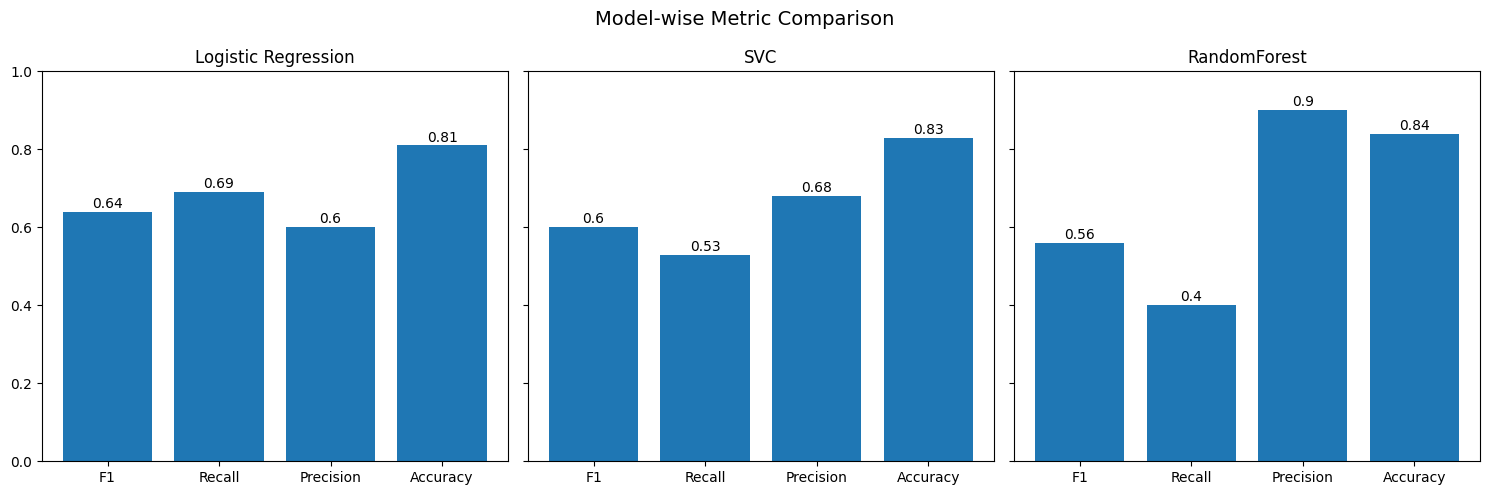

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (model, vals) in zip(axs, scores.items()):
    ax.bar(metrics, vals)
    ax.set_title(model)
    ax.set_ylim(0, 1)

    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, round(v, 2), ha="center")

fig.suptitle("Model-wise Metric Comparison", fontsize=14)
plt.tight_layout()
plt.show()


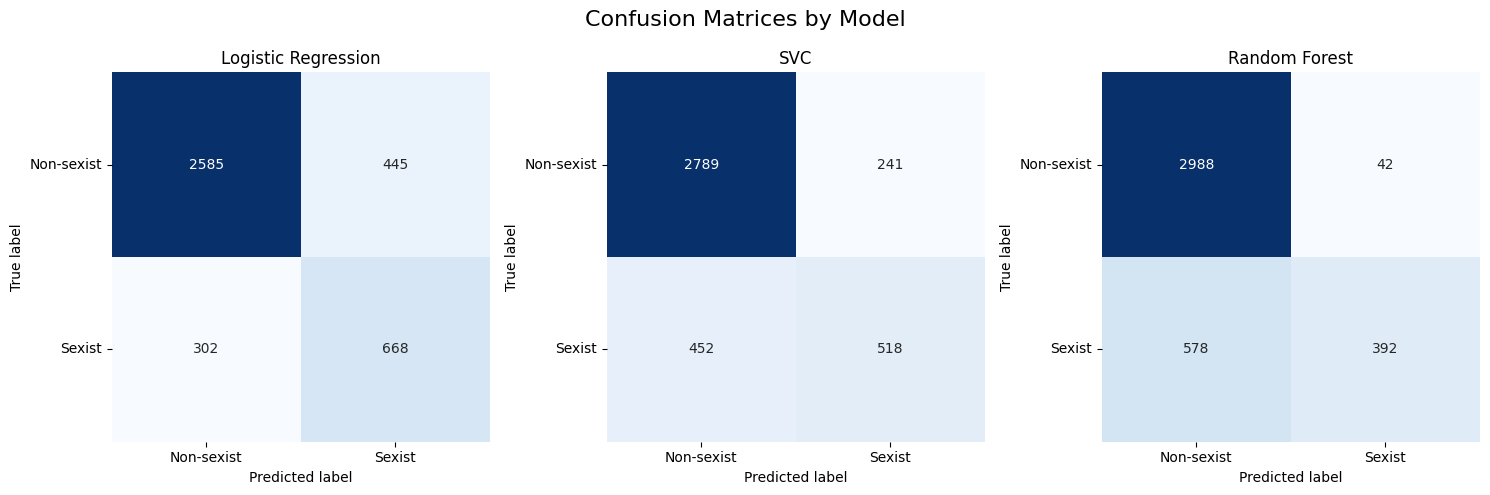

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, (model, y_pred) in zip(axs, y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False
    )

    ax.set_title(model)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticklabels(["Non-sexist", "Sexist"])
    ax.set_yticklabels(["Non-sexist", "Sexist"], rotation=0)

fig.suptitle("Confusion Matrices by Model", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
logreg_scores = log_reg.predict_proba(x_test)[:, 1]
rfc_scores = rfc.predict_proba(x_test)[:, 1]
svc_scores = svc.decision_function(x_test)

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_scores)
fpr_svc, tpr_svc, _ = roc_curve(y_test, svc_scores)
fpr_rfc, tpr_rfc, _ = roc_curve(y_test, rfc_scores)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svc = auc(fpr_svc, tpr_svc)
auc_rfc = auc(fpr_rfc, tpr_rfc)

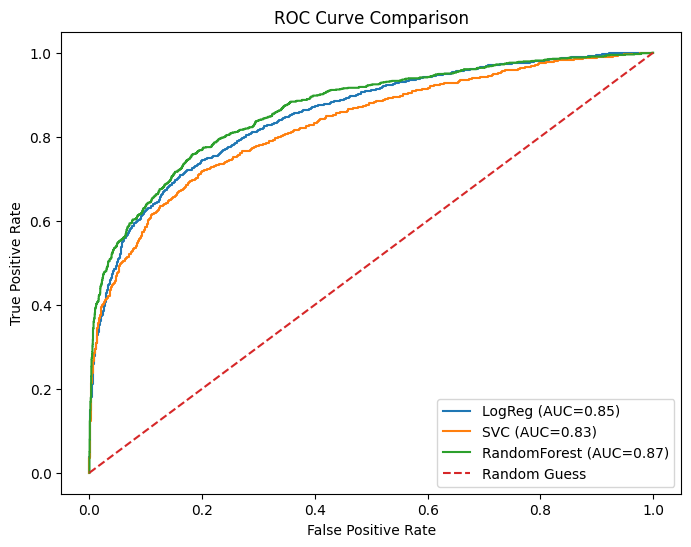

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={auc_lr:.2f})")
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC={auc_svc:.2f})")
plt.plot(fpr_rfc, tpr_rfc, label=f"RandomForest (AUC={auc_rfc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()